[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Antes esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual require de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Este técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la semgentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
#blob_centers = np.array( [[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],[-2.8,  2.8], [-2.8,  1.3]])
# blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
#blob_std = np.array([0.7, 0.7, 0.7, 0.7, 0.7]) # la dispersión de los clusters
#X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=42)
import random

# Número aleatorio de centros entre 1 y 20
n_centers = random.randint(1, 10)
#n_centers = 5

# Generar centros aleatorios separados adecuadamente
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)  # desviación estándar uniforme


from sklearn.datasets import make_blobs
#X, y = make_blobs(n_samples=1000, centers=blob_centers, cluster_std=blob_std, random_state=42)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)




#print(f"Se generaron {n_centers} clusters con {'X' if fix_x else 'Y'} fijo en {fixed_value}")
print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 10
Coordenadas de los centroides:
[[ 1.74870959 -4.06457129]
 [-0.24931816 -4.91197665]
 [-5.48782107 -3.86531415]
 [-1.96279234 -8.47917369]
 [ 8.23302597 -5.59191323]
 [-0.78469842 -2.36856535]
 [ 8.1941637   2.80046201]
 [-6.66806091  6.38971121]
 [ 1.70556574  5.72963347]
 [ 4.34036332 -3.36590577]]


In [30]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

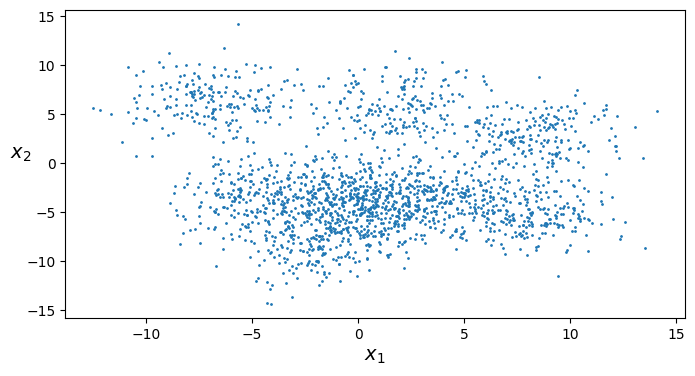

In [31]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [32]:
from sklearn.cluster import KMeans
k = len(blob_centers)
#k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred         #devolver las etiques de cada grupo y

array([3, 8, 0, ..., 7, 3, 5], dtype=int32)

In [33]:
kmeans.cluster_centers_  # centro de los clusters

array([[-2.50679588, -8.53650091],
       [ 8.06136915,  4.10340369],
       [-0.73431347, -2.59807517],
       [-6.93636146,  6.49398251],
       [-5.33889355, -3.31456626],
       [ 8.26822777, -5.67246066],
       [ 1.69904463,  5.8939604 ],
       [ 1.34812266, -6.00692069],
       [ 4.03007244, -2.66587963],
       [ 8.79042763,  0.3185821 ]])

In [34]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])  #Predecir nuevas ubicaciones
kmeans.predict(X_new)

array([6, 6, 3, 2], dtype=int32)

In [35]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

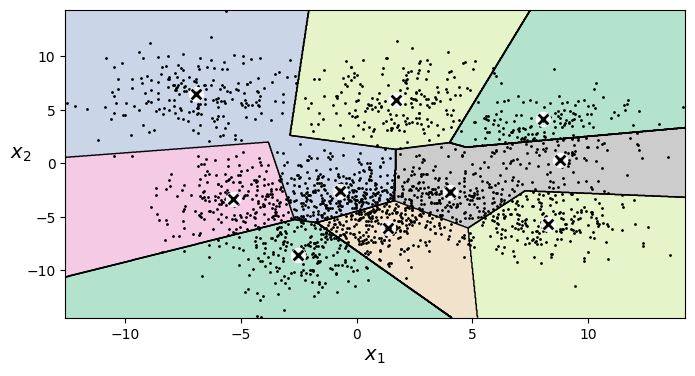

In [36]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [37]:
kmeans.transform(X_new)  # la  distancia de cada punto del X_neww

array([[10.83059911,  8.33126518,  4.65634101,  8.26492523,  7.53315332,
        11.27963842,  4.24849153,  8.11961906,  6.16538049,  8.94979241],
       [11.88876159,  5.48103683,  5.92346119, 10.90537289,  9.88846602,
         9.30703371,  4.10553437,  8.17554143,  4.77823   ,  6.02961179],
       [11.54703873, 11.11626678,  6.03918712,  5.2633502 ,  6.73380799,
        14.2191607 ,  5.51869796, 10.00153943,  9.0290703 , 12.09149229],
       [11.04751568, 11.17697592,  5.57886242,  5.60774802,  6.26734424,
        13.91984448,  5.79654963,  9.55373593,  8.72400315, 11.99052826]])

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [38]:


# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(algorithm='elkan', max_iter=3, n_clusters=10, n_init=1, random_state=1)

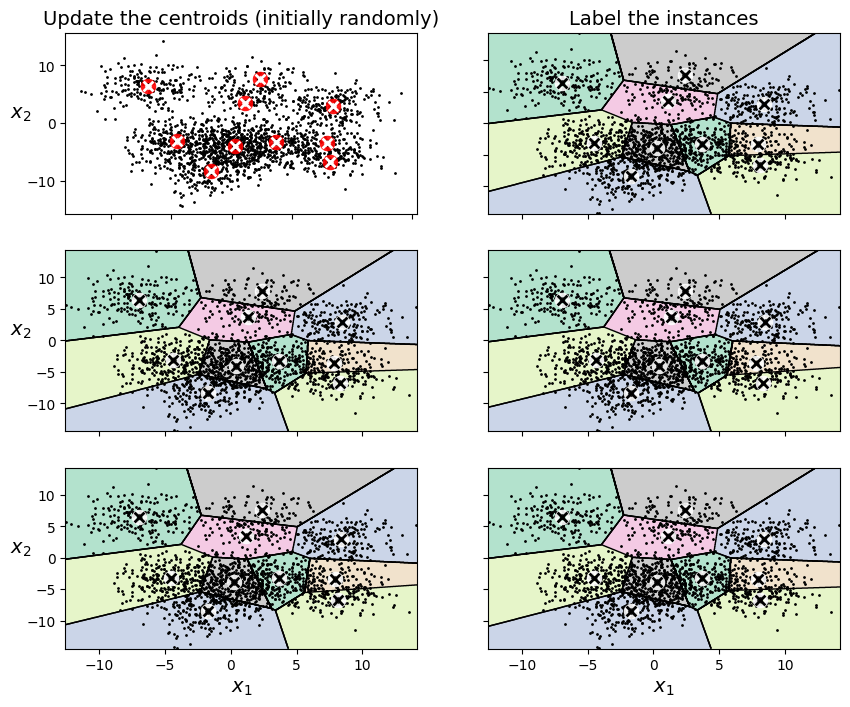

In [39]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [41]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

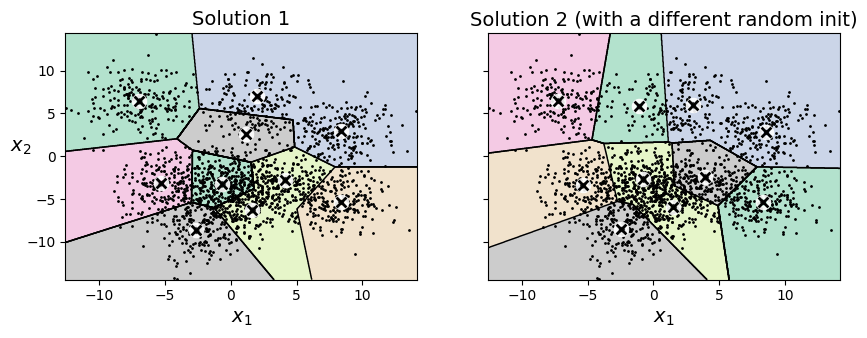

In [42]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [43]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)        # inicializando 10 y quedandome con el mejor resultado
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=10, n_init=10,
       random_state=11)

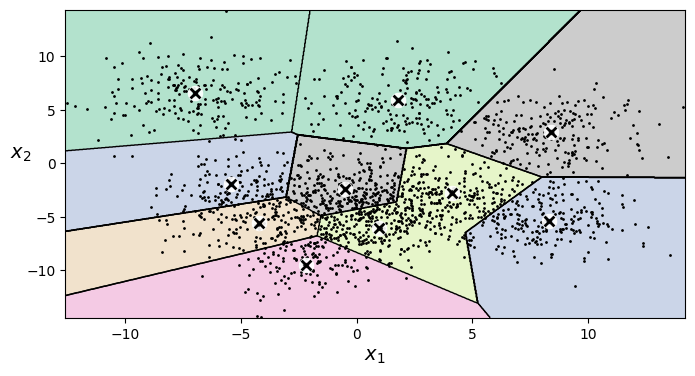

In [44]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Otras mejoras al algoritmo de *K-Means* incluyen: *K-Means* acelerados (usado por *Scikit-Learn* por defecto y que evita algunos cálculos de distancias) y *mini-batch K-Means* (que puedes usarse si el dataset es tan grande que no cabe en memoria). Vamos a ver un ejemplo de este último caso con el dataset MNIST, para lo cual usaremos el objeto [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html?highlight=minibatchkmeans#sklearn.cluster.MiniBatchKMeans).

In [45]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.target = mnist.target.astype(np.int64)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    mnist["data"], mnist["target"], random_state=42)

In [48]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [49]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None # aqui creamosS variable para guardar el mejor modelo entrenado
# el entrenamiento de Mini-bacht kmeans
for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [50]:
best_kmeans.score(X)

-23160.0813410994

El algoritmo de *mini-batch K-Means* es más rápido que *K-Means* normal, pero su precisión suele ser peor.

### Encontrando el número óptimo de grupos

Como hemos visto anteriormente, el número de grupos o *clusters* es un hyperparámetro del modelo que debemos definir, y como podrás imaginar si nuestros datos no están etiquetados no será imposible saber qué valor usar. Para ello la solución se basa en usar diferentes valores y utilizar alguna métrica significativa. Una de estas métricas se conoce como el *silhouette score*, que se basa en calcular el coeficiente de silueta (*silhouette coefficient*) de todas las muestras del dataset como $(b-a)/\mathrm{max}(a,b)$ donde $a$ es la distancia mínima al resto de muestras del mismo grupo y $b$ es la distancia media de los grupos más cercanos. Su valor se encuentra entre $1$ y $-1$. Un valor cercano a $1$ indica que la muestra está bien metida en su grupo y lejos de los demás mientras que un valor cercano a $0$ indica que la muestra se encuentra cerca de una frontera de decisión y un valor cercano a $-1$ indica que la muestra está en el grupo incorrecto.

In [51]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.37817069948683063)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

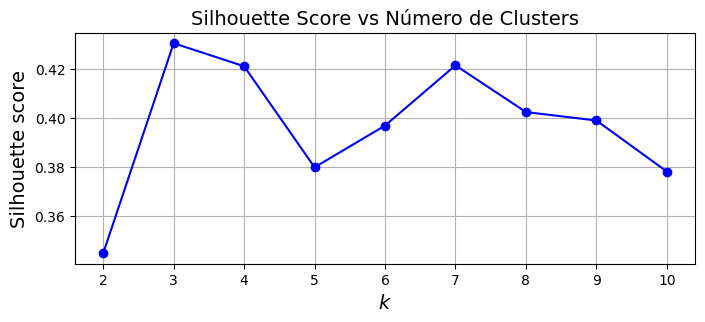

In [52]:
#kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
#silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

#max_k = min(20, len(blob_centers))  # no más de los centros generados
#kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
#silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

#plt.figure(figsize=(8, 3))
#plt.plot(range(2, 10), silhouette_scores, "bo-")
#plt.xlabel("$k$", fontsize=14)
#plt.ylabel("Silhouette score", fontsize=14)
#plt.axis([1.8, 8.5, 0.55, 0.7])
#plt.show()

import matplotlib.pyplot as plt

# Definir máximo valor de k
max_k = min(20, len(blob_centers))

# Entrenar un modelo KMeans para cada k de 1 hasta max_k
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]

# Calcular silhouette_scores para k ≥ 2
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

# Generar eje x para k de 2 hasta max_k
ks = list(range(2, max_k + 1))

# Graficar
plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

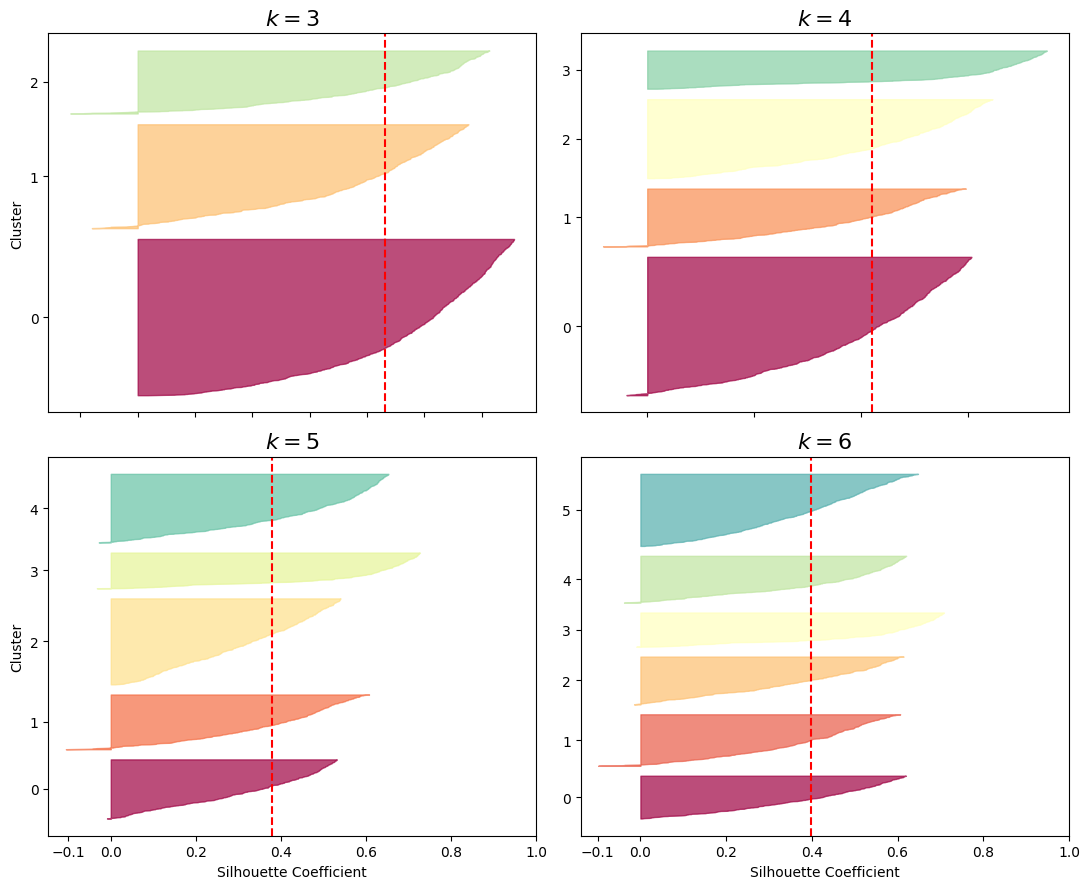

In [53]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.tight_layout()
plt.show()


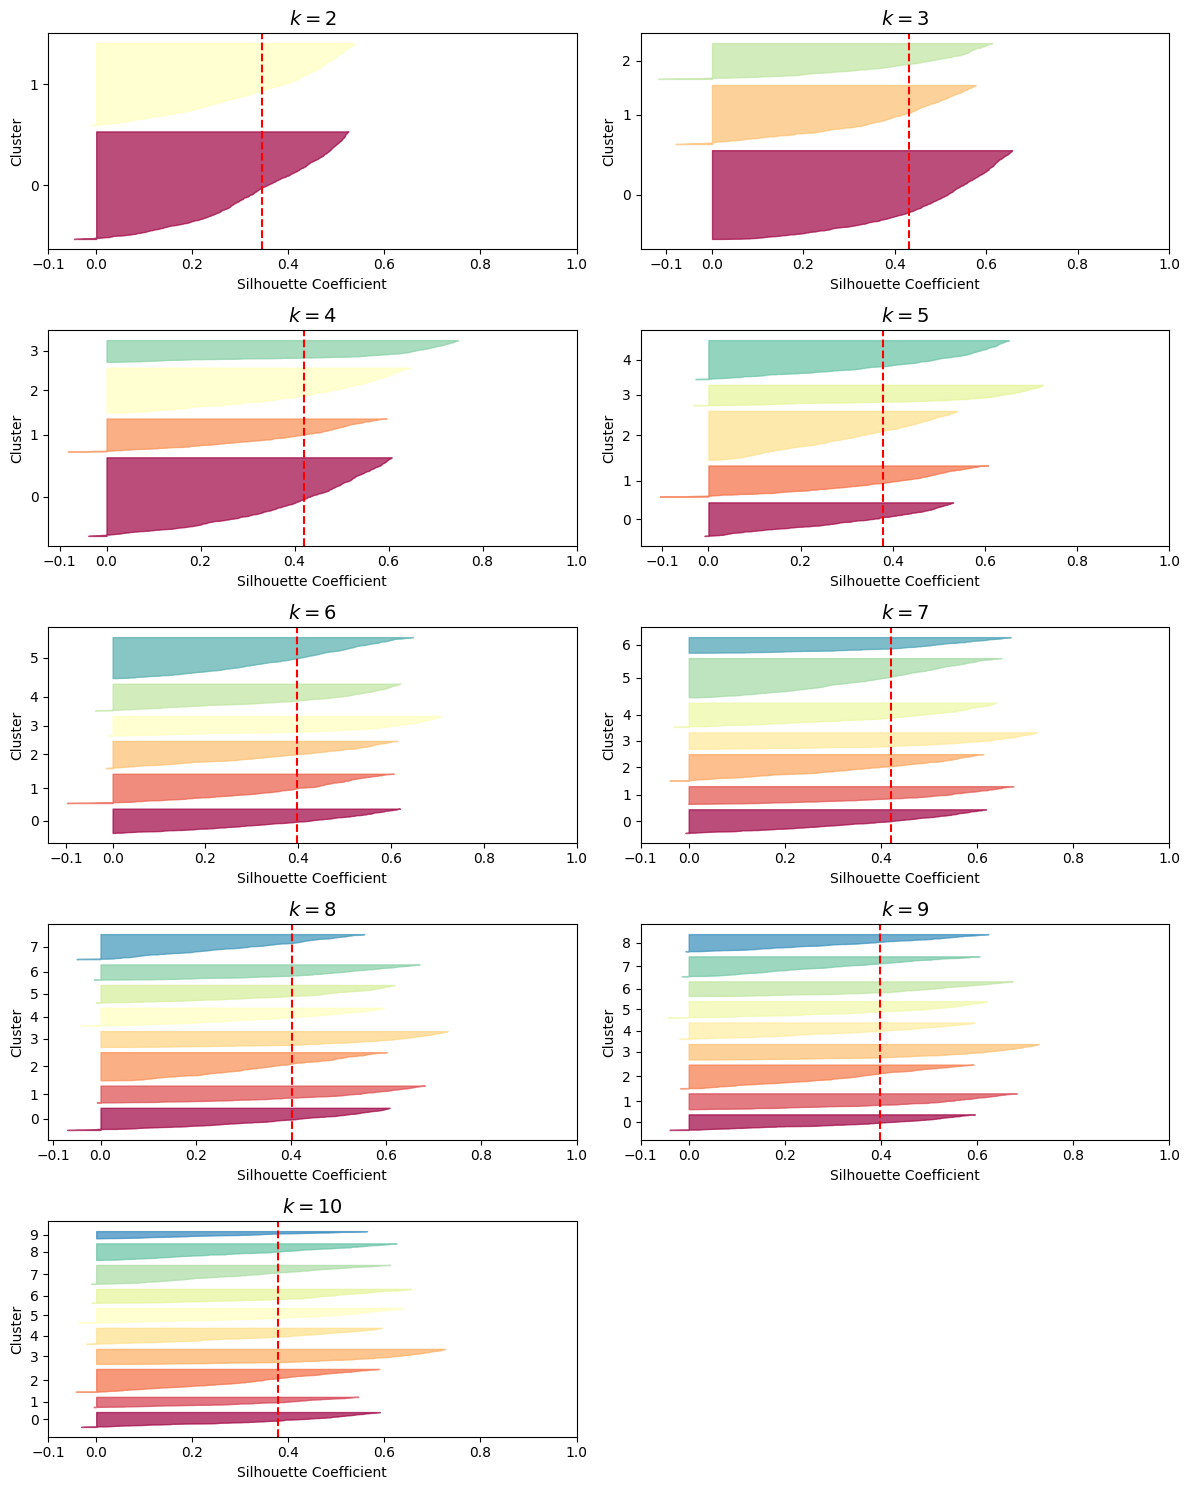

In [54]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


### K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado (o *Semi-supervised Learning*) comprende el conjunto de técnicas que nos permiten entrenar modelos con datasets parcialmente etiquetados. En esta sección vamos a ver un ejemplo de como podemos aplicar esta técnica con el dataset MNIST y usando *K-Means*. Empezamos descargando el dataset.

In [ ]:
from sklearn.datasets import fetch_lfw_people


# Cargar el dataset con imágenes de al menos 70 rostros por persona (puedes ajustar min_faces_per_person)
lfw_dataset = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Acceder a los datos
X = lfw_dataset.data          # Imágenes en formato vectorizado (flattened)
y = lfw_dataset.target        # Etiquetas (persona)
target_names = lfw_dataset.target_names  # Nombres de las personas

# Verificar las dimensiones
print("Shape de X:", X.shape)
print("Número de clases:", len(target_names))


In [ ]:
import matplotlib.pyplot as plt

# Mostrar las primeras 10 imágenes del dataset
fig, axes = plt.subplots(1, 10, figsize=(15, 8))
for i in range(10):
    axes[i].imshow(lfw_dataset.images[i], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(target_names[y[i]][:10])  # mostrar el nombre
plt.tight_layout()
plt.show()


In [ ]:
#preparar el dataset
from sklearn.model_selection import train_test_split
import numpy as np

# Cargamos el dataset
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

X = lfw.data  # características (imagenes aplanadas)
y = lfw.target  # etiquetas (personas)
target_names = lfw.target_names  # nombres de personas

print("Shape de X:", X.shape)  # ejemplo: (1288, 1850)
print("Cantidad de clases:", len(target_names))

# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


In [ ]:
from sklearn.cluster import KMeans

k = 50  # número de clusters
kmeans = KMeans(n_clusters=k, random_state=42)
X_faces_dist = kmeans.fit_transform(X_train)  # distancia a cada centroide

print("Shape de distancias:", X_faces_dist.shape)


In [ ]:
idxs = np.argmin(X_faces_dist, axis=0)  # índice más cercano a cada centroide
X_representative_faces = X_train[idxs]  # imágenes representativas

print("Shape:", X_representative_faces.shape)


In [ ]:
import matplotlib.pyplot as plt

h, w = lfw.images.shape[1:3]  # alto y ancho original

plt.figure(figsize=(15, 6))
for index, face in enumerate(X_representative_faces):
    plt.subplot(5, 10, index + 1)
    plt.imshow(face.reshape(h, w), cmap="gray")
    plt.title(f"{index+1}", fontsize=8)
    plt.axis('off')
plt.suptitle("Imágenes más representativas por cluster", fontsize=16)
plt.show()


In [ ]:
# Obtener las etiquetas reales de las imágenes más representativas
y_representative_faces = y_train[idxs]


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_faces, y_representative_faces)

# Evaluamos el modelo en el conjunto de prueba
print("Precisión usando solo imágenes representativas:", log_reg2.score(X_test, y_test))




In [ ]:
log_reg_random = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg_random.fit(X_train[:50], y_train[:50])

# Evaluamos el modelo en el conjunto de prueba
print("Precisión usando 50 imágenes aleatorias:", log_reg_random.score(X_test, y_test))



In [ ]:
# Propagación de etiquetas representativas a todo el conjunto de entrenamiento
y_train_propagated = np.empty(len(X_train))
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_faces[i]

# Entrenamiento con las etiquetas propagadas
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])

print("Precisión con 1000 muestras semi-etiquetadas:", log_reg3.score(X_test, y_test))


## Aprendizaje Activo

In [ ]:
# Calculamos las probabilidades de las primeras 1000 muestras
probas = log_reg3.predict_proba(X_train[:1000])

# Obtenemos el índice de la clase más probable para cada muestra
labels_ixs = np.argmax(probas, axis=1)

# Obtenemos la confianza (probabilidad máxima) de cada predicción
confidences = probas[np.arange(len(probas)), labels_ixs]



In [ ]:
# Ordenamos por confianza (de menor a mayor)
sorted_ixs = np.argsort(confidences)

k = 50  # cantidad de muestras "inciertas" a revisar

# Obtenemos las 50 imágenes más inciertas
X_lowest = X_train[:1000][sorted_ixs[:k]]
y_lowest = y_train[:1000][sorted_ixs[:k]]


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(10):
    for j in range(5):
        idx = i * 5 + j
        image = X_lowest[idx].reshape(50, 37)
        plt.subplot(10, 5, idx + 1)
        plt.imshow(image, cmap="gray")
        plt.axis("off")
plt.suptitle("50 imágenes más inciertas según el modelo")
plt.tight_layout()
plt.show()


In [ ]:
log_reg_active = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Entrenamos con las 50 muestras inciertas (suponemos que ya están etiquetadas correctamente)
%time log_reg_active.fit(X_lowest, y_lowest)

# Evaluamos en el conjunto de prueba
print("Precisión usando aprendizaje activo (50 imágenes inciertas):", log_reg_active.score(X_test, y_test))
